In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/icr-identify-age-related-conditions/sample_submission.csv
/kaggle/input/icr-identify-age-related-conditions/greeks.csv
/kaggle/input/icr-identify-age-related-conditions/train.csv
/kaggle/input/icr-identify-age-related-conditions/test.csv


In [2]:
df = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')
columns = df.columns

print(columns)

Index(['Id', 'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Class'],
      dtype='object')


<Axes: >

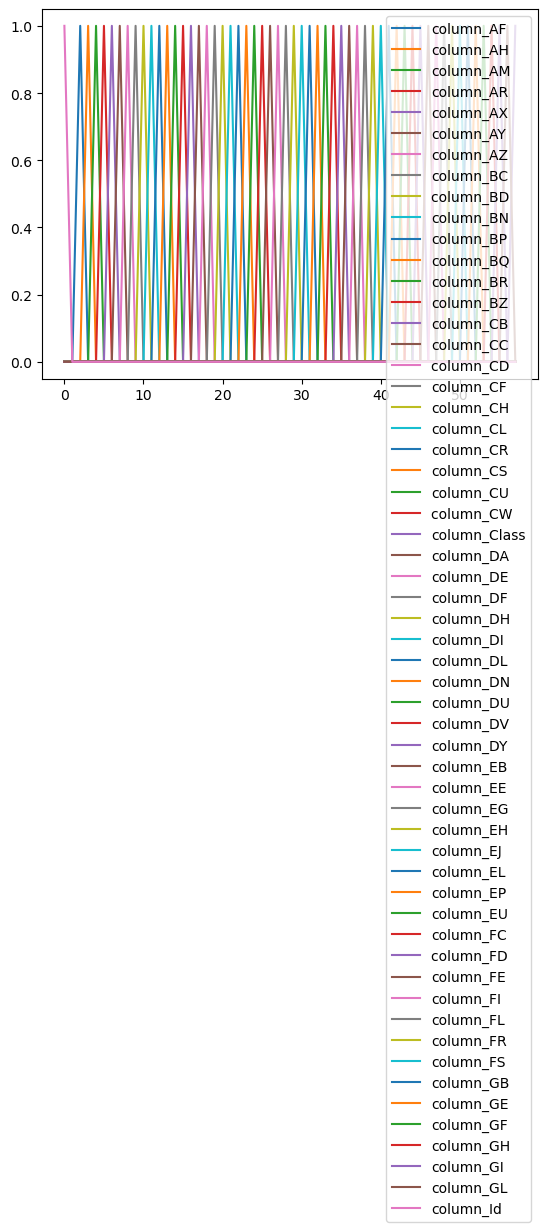

In [3]:
import numpy as np
import pandas as pd

def one_hot_encode(df, column):

  unique_values = np.unique(df[column])
  encoded_df = pd.get_dummies(df[column], prefix=column, drop_first=True)

  return df.join(encoded_df)

if __name__ == "__main__":
  df = pd.DataFrame({
    "column":['Id', 'AB', 'AF', 'AH', 'AM', 'AR', 'AX', 'AY', 'AZ', 'BC', 'BD ', 'BN',
       'BP', 'BQ', 'BR', 'BZ', 'CB', 'CC', 'CD ', 'CF', 'CH', 'CL', 'CR', 'CS',
       'CU', 'CW ', 'DA', 'DE', 'DF', 'DH', 'DI', 'DL', 'DN', 'DU', 'DV', 'DY',
       'EB', 'EE', 'EG', 'EH', 'EJ', 'EL', 'EP', 'EU', 'FC', 'FD ', 'FE', 'FI',
       'FL', 'FR', 'FS', 'GB', 'GE', 'GF', 'GH', 'GI', 'GL', 'Class']
  })

encoded_df = one_hot_encode(df, "column")
encoded_df.plot()

In [4]:
columns = encoded_df.columns

print(columns)

Index(['column', 'column_AF', 'column_AH', 'column_AM', 'column_AR',
       'column_AX', 'column_AY', 'column_AZ', 'column_BC', 'column_BD ',
       'column_BN', 'column_BP', 'column_BQ', 'column_BR', 'column_BZ',
       'column_CB', 'column_CC', 'column_CD ', 'column_CF', 'column_CH',
       'column_CL', 'column_CR', 'column_CS', 'column_CU', 'column_CW ',
       'column_Class', 'column_DA', 'column_DE', 'column_DF', 'column_DH',
       'column_DI', 'column_DL', 'column_DN', 'column_DU', 'column_DV',
       'column_DY', 'column_EB', 'column_EE', 'column_EG', 'column_EH',
       'column_EJ', 'column_EL', 'column_EP', 'column_EU', 'column_FC',
       'column_FD ', 'column_FE', 'column_FI', 'column_FL', 'column_FR',
       'column_FS', 'column_GB', 'column_GE', 'column_GF', 'column_GH',
       'column_GI', 'column_GL', 'column_Id'],
      dtype='object')


In [5]:
data = encoded_df.drop('column', axis=1)
columns = data.columns

print(columns)

Index(['column_AF', 'column_AH', 'column_AM', 'column_AR', 'column_AX',
       'column_AY', 'column_AZ', 'column_BC', 'column_BD ', 'column_BN',
       'column_BP', 'column_BQ', 'column_BR', 'column_BZ', 'column_CB',
       'column_CC', 'column_CD ', 'column_CF', 'column_CH', 'column_CL',
       'column_CR', 'column_CS', 'column_CU', 'column_CW ', 'column_Class',
       'column_DA', 'column_DE', 'column_DF', 'column_DH', 'column_DI',
       'column_DL', 'column_DN', 'column_DU', 'column_DV', 'column_DY',
       'column_EB', 'column_EE', 'column_EG', 'column_EH', 'column_EJ',
       'column_EL', 'column_EP', 'column_EU', 'column_FC', 'column_FD ',
       'column_FE', 'column_FI', 'column_FL', 'column_FR', 'column_FS',
       'column_GB', 'column_GE', 'column_GF', 'column_GH', 'column_GI',
       'column_GL', 'column_Id'],
      dtype='object')


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, data['column_Class'], test_size=0.25)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [8]:
score = model.score(X_test, y_test)
print(score)


1.0


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data[['column_AF', 'column_AH', 'column_AM', 'column_AR', 'column_AX',
       'column_AY', 'column_AZ', 'column_BC', 'column_BD ', 'column_BN',
       'column_BP', 'column_BQ', 'column_BR', 'column_BZ', 'column_CB',
       'column_CC', 'column_CD ', 'column_CF', 'column_CH', 'column_CL',
       'column_CR', 'column_CS', 'column_CU', 'column_CW ', 'column_Class',
       'column_DA', 'column_DE', 'column_DF', 'column_DH', 'column_DI',
       'column_DL', 'column_DN', 'column_DU', 'column_DV', 'column_DY',
       'column_EB', 'column_EE', 'column_EG', 'column_EH', 'column_EJ',
       'column_EL', 'column_EP', 'column_EU', 'column_FC', 'column_FD ',
       'column_FE', 'column_FI', 'column_FL', 'column_FR', 'column_FS',
       'column_GB', 'column_GE', 'column_GF', 'column_GH', 'column_GI',
       'column_GL', 'column_Id']], data['column_Class'], test_size=0.25)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)

print("Accuracy:", accuracy)

Accuracy: 1.0
